In [2]:
import csv
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import os

In [4]:
import json
import random
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, classification_report
from confidenceinterval_local.confidenceinterval.classification_report import classification_report_with_ci
import seaborn as sns

# MeSH and Keywords Analysis

## Create IDs from the current data

In [8]:
ds_test = pd.read_csv("../../data/data_splits_stratified/6-2-2_all_classes_enriched/test.csv")
ds_train = pd.read_csv("../../data/data_splits_stratified/6-2-2_all_classes_enriched/train.csv")
ds_val = pd.read_csv("../../data/data_splits_stratified/6-2-2_all_classes_enriched/val.csv")

In [10]:
len(ds_test) + len(ds_train) + len(ds_val)

2645

In [12]:
# Concatenate (append) the DataFrames vertically
appended_df = pd.concat([ds_test, ds_train, ds_val], ignore_index=True)

In [14]:
appended_df.head()


,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,Non-systematic-review,1,0
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Non-systematic-review,1,0
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,Non-systematic-review,1,0
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,Non-systematic-review,1,0
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,Non-systematic-review,1,0


In [16]:
df_to_fetch_from_doi = pd.read_csv("../../data/rayyan_to_pmid_258.csv")
df_to_fetch_from_doi['pmid_from_doi'] = df_to_fetch_from_doi['pmid_from_doi'].astype(str)

In [18]:
merged_df = pd.merge(appended_df, df_to_fetch_from_doi[['pmid', 'pmid_from_doi']], how='left', on='pmid')
merged_df['old_pmid'] = merged_df['pmid']
merged_df.head()

,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label,pmid_from_doi,old_pmid
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,Non-systematic-review,1,0,NaN,12047012
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Non-systematic-review,1,0,NaN,28832188
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,Non-systematic-review,1,0,NaN,17678496
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,Non-systematic-review,1,0,NaN,25649308
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,Non-systematic-review,1,0,NaN,6312596


In [20]:
# Your map of rayyan PMIDs to replace
rayyan_pmid_map = {
    'rayyan-1277751880': 10875051,
    'rayyan-1277750218': 50014,
    'rayyan-1277751843': 11142548,
    'rayyan-1270409883': 6380400,
    'rayyan-1270413930': 22493342,
    'rayyan-1270414149': 23413122
}

# Custom function to replace 'pmid' values based on conditions and the rayyan_pmid_map
def replace_pmid(row):
    if 'rayyan' in row['pmid'] and not pd.isnull(row['pmid_from_doi']):
        return row['pmid_from_doi']
    elif 'rayyan' in row['pmid']:
        return rayyan_pmid_map.get(row['pmid'], row['pmid'])
    else:
        return row['pmid']

# Apply the custom function to create a new 'pmid' column
merged_df['pmid'] = merged_df.apply(replace_pmid, axis=1)
merged_df.drop(columns=['pmid_from_doi'], inplace=True)

merged_df.head()

,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label,old_pmid
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,Non-systematic-review,1,0,12047012
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Non-systematic-review,1,0,28832188
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,Non-systematic-review,1,0,17678496
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,Non-systematic-review,1,0,25649308
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,Non-systematic-review,1,0,6312596


In [22]:
merged_df[merged_df['pmid'].isna() | merged_df['pmid'].str.contains('rayyan', case=False)]


,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label,old_pmid


In [24]:
# Keep only the 'pmid' column
pmid_column = merged_df['pmid']
pmid_column

0       12047012
1       28832188
2       17678496
3       25649308
4        6312596
          ...   
2640    27511183
2641    11520467
2642    36472596
2643    36632763
2644    23703687
Name: pmid, Length: 2645, dtype: object

## Read data with MeSH

In [27]:
file_path = "../../data/pubmed/pmid_mesh_terms.txt"

# Read the file into a pandas DataFrame
df_mesh = pd.read_csv(file_path, sep="^", header=None, engine="python", names=["PMID", "MeSH_Terms"])
df_mesh["MeSH_Terms"] = df_mesh["MeSH_Terms"].str.replace("\t", ", ")  # Convert tab to comma for readability


#### missing MeSH

In [30]:
missing_mesh = df_mesh["MeSH_Terms"].isna().sum() + (df_mesh["MeSH_Terms"].astype(str).str.strip() == "").sum()
print(missing_mesh)
# Calculate percentage
percentage_with = ((len(df_mesh)-missing_mesh) / len(df_mesh)) * 100
percentage_with

18


99.31947069943288

In [32]:
df_mesh.rename(columns={'PMID': 'pmid'}, inplace=True)
df_mesh["pmid"] = df_mesh["pmid"].astype(str)

enriched_ds_with_mesh = merged_df.merge(df_mesh, on='pmid', how='left')
enriched_ds_with_mesh["MeSH_Label"] = enriched_ds_with_mesh["MeSH_Terms"].str.contains("animal", case=False, na=False).map({True: "Animal", False: "Other"})

enriched_ds_with_mesh.head()

,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label,old_pmid,MeSH_Terms,MeSH_Label
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,Non-systematic-review,1,0,12047012,"Antipsychotic Agents, Critical Pathways, Drug ...",Other
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Non-systematic-review,1,0,28832188,"Acetylcholinesterase, Alzheimer Disease, Amylo...",Other
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,Non-systematic-review,1,0,17678496,"Humans, Learning, Occupational Therapy, Patien...",Other
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,Non-systematic-review,1,0,25649308,"Anhedonia, Antidepressive Agents, Cognition, D...",Other
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,Non-systematic-review,1,0,6312596,"Adrenal Cortex Hormones, Alcoholism, Contracep...",Other


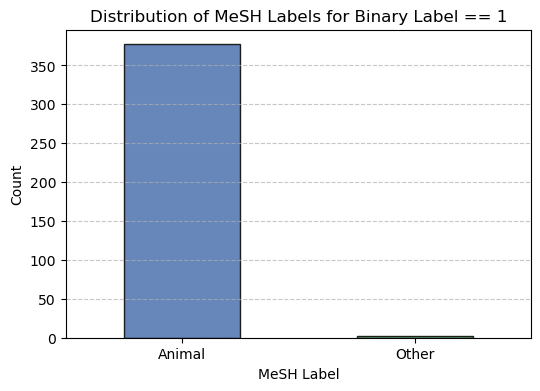

In [34]:
filtered_df = enriched_ds_with_mesh[enriched_ds_with_mesh["binary_label"] == 1]

# Count occurrences of each MeSH_Label category
mesh_label_counts = filtered_df["MeSH_Label"].value_counts()

# Plot the distribution
plt.figure(figsize=(6, 4))
mesh_label_counts.plot(kind="bar", color=['#4c72b0', '#55a868'], edgecolor="black", alpha=0.85)
plt.title("Distribution of MeSH Labels for Binary Label == 1")
plt.xlabel("MeSH Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

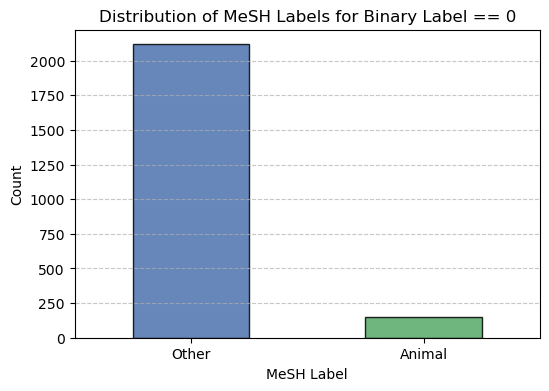

In [36]:
filtered_df = enriched_ds_with_mesh[enriched_ds_with_mesh["binary_label"] == 0]

# Count occurrences of each MeSH_Label category
mesh_label_counts = filtered_df["MeSH_Label"].value_counts()

# Plot the distribution
plt.figure(figsize=(6, 4))
mesh_label_counts.plot(kind="bar", color=['#4c72b0', '#55a868'], edgecolor="black", alpha=0.85)
plt.title("Distribution of MeSH Labels for Binary Label == 0")
plt.xlabel("MeSH Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

In [38]:
enriched_ds_with_mesh["labels_mesh_binary"] = enriched_ds_with_mesh["MeSH_Label"].apply(lambda x: 1 if "Animal" in x else 0)


In [40]:
def evaluate_predictions_with_ci(model, df, true_col, prediction_col, label_to_numerical, numerical_to_label, digits=3):
    report_dfs = []
    summary_stats = []

    # Extract arrays for evaluation
    y_true = df[true_col].values
    y_pred = df[prediction_col].values
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_to_numerical)))
    
    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)  # Replace NaN with 0
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    accuracy_balanced = balanced_accuracy_score(y_true, y_pred)

    report = classification_report_with_ci(y_true, y_pred, numerical_to_label_map=numerical_to_label, round_ndigits=digits)
    
    # Create DataFrame from report
    report_df = pd.DataFrame(report)
    report_dfs.append(report_df)
    
    # Extract summary statistics
    report_df.set_index('class', inplace=True)
    #summary = report_df.loc['weighted avg', ['precision', 'precision CI', 'recall', 'recall CI', 'f1-score', 'f1-score CI', 'accuracy', 'accuracy CI']].to_dict()
    #summary_stats.append(summary)

    # Plotting normalized confusion matrix
    plt.figure(figsize=(12, 7.5))
    ax = sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', xticklabels=range(len(label_to_numerical)), yticklabels=range(len(label_to_numerical)))
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=13)
    plt.title(f'{model}', fontsize=14)
    plt.xlabel('Predicted', fontsize=13)
    plt.ylabel('True', fontsize=13)

    # Add an inset with label mapping
    textstr = '\n'.join([f'{v}: {k}' for k, v in label_to_numerical.items()])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
    ax.text(1.16, 1.0, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    plt.tight_layout()
    plt.savefig(f'./viz/{model}.pdf')
    plt.show()

    # Combine all report DataFrames
    all_reports_df = pd.concat(report_dfs)
    # Create a summary table for average precision, recall, and F1-score
    summary_df = pd.DataFrame(summary_stats)

    return all_reports_df, summary_df

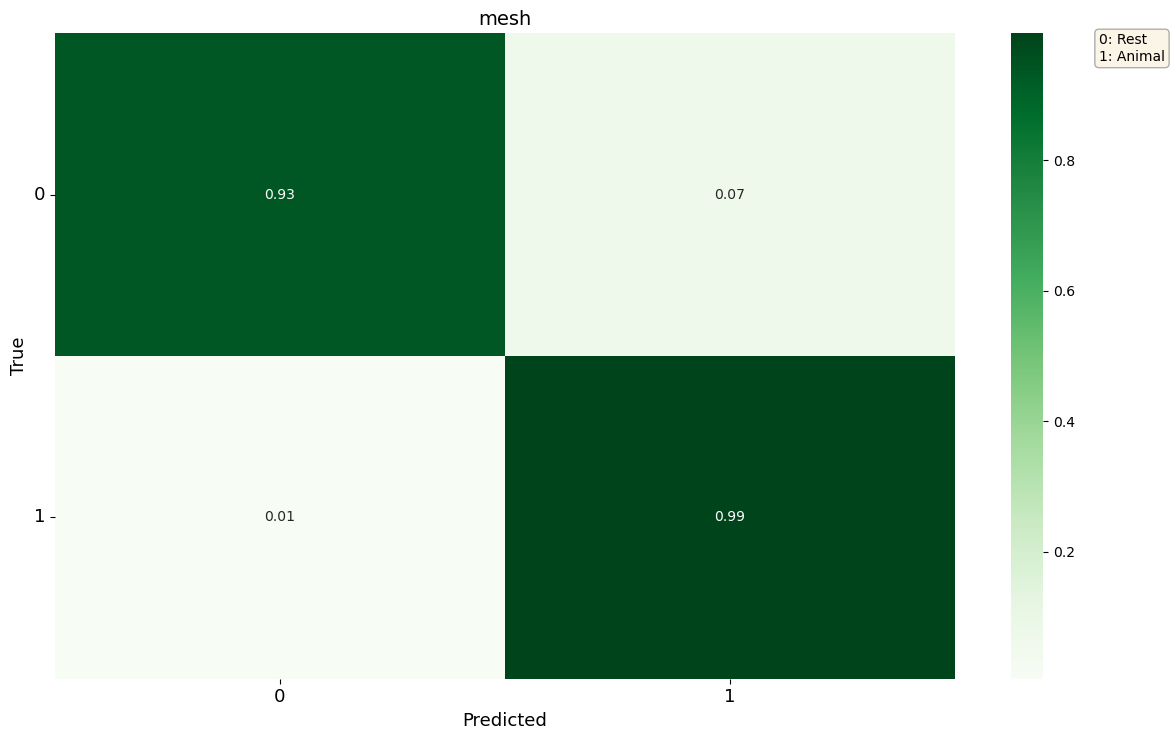

In [42]:
label_to_numerical = {
    'Rest': 0,
    'Animal': 1
}
numerical_to_label = {v: f"{k}" for k, v in label_to_numerical.items()}

true_col = 'binary_label'
prediction_col = 'labels_mesh_binary'
model = 'mesh'
all_reports_df, summary_df =evaluate_predictions_with_ci(model, enriched_ds_with_mesh, true_col, prediction_col, label_to_numerical, numerical_to_label, digits=3)

In [49]:
all_reports_df

,precision,recall,f1-score,accuracy,precision CI,recall CI,f1-score CI,accuracy CI,support
class,,,,,,,,,
Rest,0.999,0.935,0.966,0.943,"(0.997, 1.0)","(0.924, 0.944)","(0.957, 0.974)","(0.934, 0.951)",2266
Animal,0.718,0.995,0.834,0.943,"(0.678, 0.755)","(0.981, 0.999)","(0.807, 0.862)","(0.934, 0.951)",379
micro,0.943,0.943,0.943,NaN,"(0.934, 0.952)","(0.934, 0.952)","(0.934, 0.952)",NaN,2645
macro,0.859,0.965,0.900,NaN,"(0.842, 0.875)","(0.952, 0.977)","(0.871, 0.928)",NaN,2645
weighted avg,0.959,0.943,0.947,0.943,"(0.954, 0.963)","(0.934, 0.952)","(0.939, 0.954)","(0.934, 0.952)",2645
accuracy,0.943,0.943,0.943,0.943,"(0.934, 0.952)","(0.934, 0.952)","(0.934, 0.952)","(0.934, 0.952)",2645


In [43]:
# Select rows from enriched_ds_with_kw based on PMIDs in ds_test
merged_test = enriched_ds_with_mesh[enriched_ds_with_mesh['old_pmid'].isin(ds_test['pmid'])]
merged_test.drop(columns=['old_pmid'], inplace=True)

# Select rows from enriched_ds_with_kw based on PMIDs in ds_train
merged_train = enriched_ds_with_mesh[enriched_ds_with_mesh['old_pmid'].isin(ds_train['pmid'])]
merged_train.drop(columns=['old_pmid'], inplace=True)

# Select rows from enriched_ds_with_kw based on PMIDs in ds_val
merged_val = enriched_ds_with_mesh[enriched_ds_with_mesh['old_pmid'].isin(ds_val['pmid'])]
merged_val.drop(columns=['old_pmid'], inplace=True)


/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_95477/3404484850.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_test.drop(columns=['old_pmid'], inplace=True)
/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_95477/3404484850.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_train.drop(columns=['old_pmid'], inplace=True)
/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_95477/3404484850.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [46]:
merged_test.to_csv("../../data/data_splits_stratified/6-2-2_all_classes_enriched_with_mesh/test.csv", index=False)
merged_train.to_csv("../../data/data_splits_stratified/6-2-2_all_classes_enriched_with_mesh/train.csv", index=False)
merged_val.to_csv("../../data/data_splits_stratified/6-2-2_all_classes_enriched_with_mesh/val.csv", index=False)

In [67]:
enriched_ds_with_kw.shape

(2645, 10)